# GLD100 row-banding artifact -- elevation-domain investigation

`docs/history.md` Phase 125 root-caused a faint horizontal streaking pattern seen in
`notebooks/isis_shadow_spike.py`'s shadow-mask renders to GLD100's own upstream DEM production
(confirmed via an independently-fetched NASA PDS source tile, not introduced by this project's
reprojection or by ISIS `shadow`) -- see `docs/data-sources/astropedia-gld100.md`. This notebook
picks that investigation back up to answer a narrower, practical question for
`docs/proposed-tasks/isis-shadow-masking.md`: is the artifact's elevation-domain footprint large
enough to detect and correct directly in the DEM, or does it only become visible after
hillshade's photometric rendering amplifies it?

Disposable, kept for reference rather than deleted -- not imported by anything, same posture as
`isis_shadow_spike.py`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import LightSource
from scipy.signal import find_peaks

import trntest
from trntest import dem_ortho, illumination

CANDIDATE_PRODUCT_ID = "M1327218454CE"  # same candidate as isis_shadow_spike.py

session = trntest.Session()
config = session.config
images = trntest.read_manifest("dataset_manifest.csv")
dataset = trntest.TrnTestDataSet.create(config.output_dir / "trn_dataset", images, config)
entry = dataset[CANDIDATE_PRODUCT_ID]
camera = entry.camera

dem_result = dem_ortho.fetch_dem(camera, entry.config)
with rasterio.open(dem_result.dem) as src:
    elevation = src.read(1, masked=True).astype("float64")
elev = np.ma.filled(elevation, np.nan)
height, width = elev.shape
minx, miny, maxx, maxy = dem_result.bbox
pixel_resolution_m = (maxx - minx) / dem_result.width
print(f"DEM: {width}x{height} px, ~{pixel_resolution_m:.1f} m/px")

ROI center (lon,lat deg): (np.float64(177.77785856883), np.float64(73.514130051066)), bbox (local m): (-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701)
ROI size 2424x2437 px (~100.0 m/px)


DEM: 2424x2437 px, ~100.0 m/px


## Reconstructing the detector

Phase 125's row-peak scan (row-mean hillshade residual against a broad rolling-median baseline)
was done in scratch cells and never committed as code. Reconstructed here, against the same
candidate's real acquisition sun geometry.

In [2]:
azimuth_deg, elevation_deg = illumination.sun_azimuth_elevation_deg(*camera.footprint_lonlat_deg["center"], camera.et)
print(f"sun azimuth/elevation at footprint center: {azimuth_deg:.2f} / {elevation_deg:.2f} deg")
light = LightSource(azdeg=azimuth_deg, altdeg=elevation_deg)
hillshade = light.hillshade(np.nan_to_num(elev, nan=np.nanmean(elev)), dx=pixel_resolution_m, dy=pixel_resolution_m)
row_mean_hillshade = np.nanmean(hillshade, axis=1)

hs_window = 9
hs_pad = hs_window // 2
hs_padded = np.pad(row_mean_hillshade, hs_pad, mode="edge")
hs_baseline = np.array([np.median(hs_padded[i : i + hs_window]) for i in range(len(row_mean_hillshade))])
hs_residual = row_mean_hillshade - hs_baseline
hs_peaks, _ = find_peaks(np.abs(hs_residual), prominence=np.nanstd(hs_residual) * 1.5, distance=10)
print(
    f"hillshade-domain peaks found: {len(hs_peaks)} "
    f"(median spacing {np.median(np.diff(hs_peaks)):.1f} rows) -- Phase 125 found 49 at ~41-row "
    f"median spacing on the same candidate; this reconstruction is in the same ballpark, not an "
    f"exact replica of whatever threshold was used interactively that night."
)

sun azimuth/elevation at footprint center: 224.44 / 13.32 deg


hillshade-domain peaks found: 61 (median spacing 27.5 rows) -- Phase 125 found 49 at ~41-row median spacing on the same candidate; this reconstruction is in the same ballpark, not an exact replica of whatever threshold was used interactively that night.


## Seeing it directly, at 1:1 pixel zoom

Everything after this point is numbers and aggregate statistics -- worth first just looking at
the actual rendered artifact, the way Phase 125 originally did (a strict 1:1-pixel-scale render,
`interpolation="none"`, specifically to rule out `matplotlib` display-resampling/moire as the
cause). Two views: a wide strip covering several streaks at once (rows 950-1250, full width --
this range alone contains 13 of the detector's flagged rows), and a tight close-up on row 1045,
the single row the fold-and-stack and raw-column-grid diagnostics above focus on.

flagged rows in [950,1250): [np.int64(960), np.int64(974), np.int64(986), np.int64(1003), np.int64(1017), np.int64(1045), np.int64(1068), np.int64(1081), np.int64(1104), np.int64(1124), np.int64(1186)]


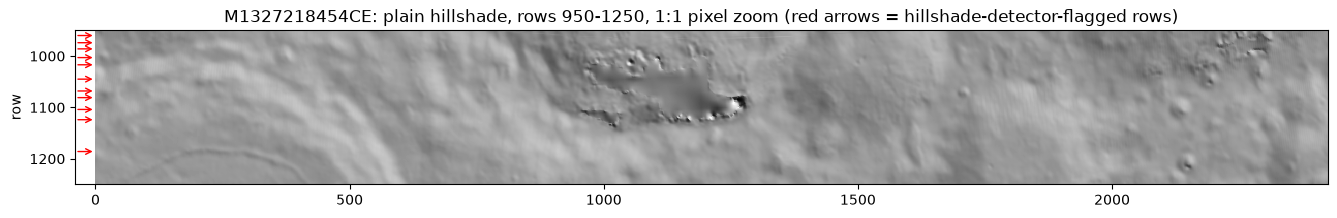

In [3]:
def show_hillshade_strip(hillshade, lo, hi, flagged_in_range, title, dpi=150):
    crop = hillshade[lo:hi, :]
    crop_h, crop_w = crop.shape
    fig, ax = plt.subplots(figsize=(crop_w / dpi, max(crop_h / dpi, 1.5)))
    ax.imshow(crop, cmap="gray", interpolation="none", extent=[0, crop_w, hi, lo], aspect="auto")
    for r in flagged_in_range:
        ax.annotate(
            "", xy=(0, r), xytext=(-40, r), arrowprops=dict(arrowstyle="->", color="red"), annotation_clip=False
        )
    ax.set_xlim(-40, crop_w)
    ax.set_ylabel("row")
    ax.set_title(title)
    return fig


lo, hi = 950, 1250
flagged_in_range = [r for r in hs_peaks if lo <= r < hi]
print(f"flagged rows in [{lo},{hi}): {flagged_in_range}")
fig = show_hillshade_strip(
    hillshade,
    lo,
    hi,
    flagged_in_range,
    f"{entry.edr_product}: plain hillshade, rows {lo}-{hi}, 1:1 pixel zoom "
    f"(red arrows = hillshade-detector-flagged rows)",
)
fig.savefig(config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_hillshade_strip_{lo}_{hi}.png", dpi=150)
plt.show()

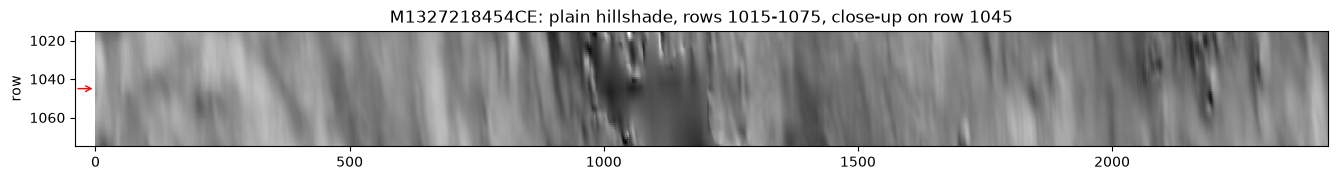

In [4]:
lo2, hi2 = 1015, 1075
fig = show_hillshade_strip(
    hillshade, lo2, hi2, [1045], f"{entry.edr_product}: plain hillshade, rows {lo2}-{hi2}, close-up on row 1045"
)
fig.savefig(config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_hillshade_closeup_1045.png", dpi=150)
plt.show()

Neither plain-hillshade view above shows an obvious line at the flagged rows, even at 1:1 zoom.
That's expected, not a display problem: Phase 125 measured the effect at ~0.1-1% relative
brightness -- roughly 0-2 gray levels out of 256 in an ordinary grayscale render, well under what
the eye can pick out against real terrain's own much larger brightness range.

First attempt at a fix: subtract `hs_baseline` (the same per-row scalar the detector uses) from
every column. That failed too -- it only removes each row's *average* brightness trend, so real 2D
terrain texture (the crater, its rim) still dominates the view untouched. What's actually needed
is a per-*column* vertical high-pass: a rolling median computed independently down each column,
which passes through slow terrain variation (removing it from the residual) while rejecting a
genuine thin single-row line (which a small vertical window's median is robust to, so it survives
into the residual).

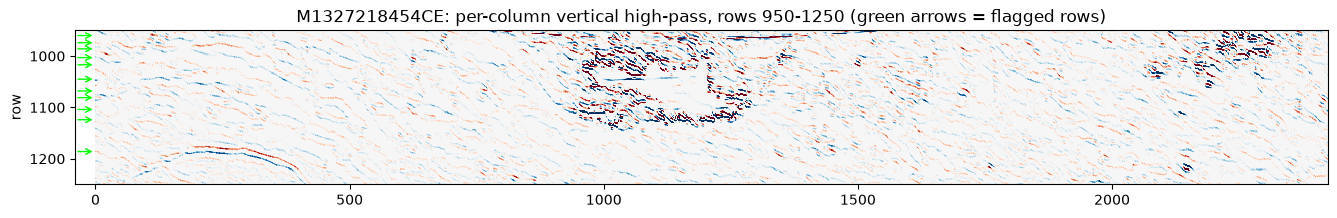

In [5]:
from scipy.ndimage import median_filter  # noqa: E402


def show_highpass_strip(hillshade, lo, hi, flagged_in_range, title, dpi=150, window=9, vmax_std=3.0):
    pad = window // 2
    padded = hillshade[max(0, lo - pad) : hi + pad, :]
    baseline_2d = median_filter(padded, size=(window, 1), mode="nearest")
    residual_2d = (padded - baseline_2d)[lo - max(0, lo - pad) : lo - max(0, lo - pad) + (hi - lo), :]
    crop_h, crop_w = residual_2d.shape
    vmax = vmax_std * np.nanstd(residual_2d)
    fig, ax = plt.subplots(figsize=(crop_w / dpi, max(crop_h / dpi, 1.5)))
    ax.imshow(
        residual_2d,
        cmap="RdBu_r",
        interpolation="none",
        extent=[0, crop_w, hi, lo],
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
    )
    for r in flagged_in_range:
        ax.annotate(
            "", xy=(0, r), xytext=(-40, r), arrowprops=dict(arrowstyle="->", color="lime"), annotation_clip=False
        )
    ax.set_xlim(-40, crop_w)
    ax.set_ylabel("row")
    ax.set_title(title)
    return fig


fig = show_highpass_strip(
    hillshade,
    lo,
    hi,
    flagged_in_range,
    f"{entry.edr_product}: per-column vertical high-pass, rows {lo}-{hi} (green arrows = flagged rows)",
)
fig.savefig(config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_hillshade_highpass_{lo}_{hi}.png", dpi=150)
plt.show()

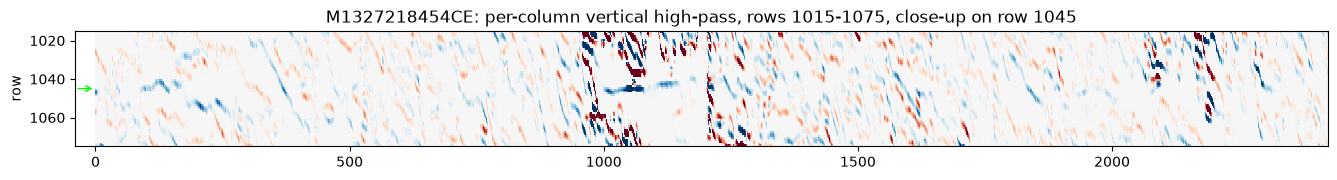

In [6]:
fig = show_highpass_strip(
    hillshade,
    lo2,
    hi2,
    [1045],
    f"{entry.edr_product}: per-column vertical high-pass, rows {lo2}-{hi2}, close-up on row 1045",
)
fig.savefig(
    config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_hillshade_highpass_closeup_1045.png", dpi=150
)
plt.show()

## Does the same signal show up directly in raw elevation?

Two magnitude-based detectors tried directly on elevation (largest per-row |diff|, and per-row
same-sign coherence) both failed for the same reason: a real, smoothly-varying regional slope
also shifts most/all columns the same direction by a similar amount, row after row, at this DEM's
~100 m/px scale -- even a shallow few-degree slope produces several-to-tens-of-meters row-to-row
shift, swamping whatever the artifact's own magnitude is. Those attempts produced 125 and 21
"seams" respectively, both dominated by real terrain (offsets estimated up to 135 m -- not a
subtle bias). The check below instead asks a narrower question: at the rows the *hillshade*
detector flags, is there even a mild elevation-magnitude anomaly, via a per-row Hampel-filter
z-score (robust local-outlier score, insensitive to the window's own background slope level)?

In [7]:
row_diff = np.diff(elev, axis=0)  # row i = elev[i+1] - elev[i]
row_median = np.nanmedian(row_diff, axis=1)  # robust to a narrow crater-wall column band

hampel_window = 11
half = hampel_window // 2
z_scores = np.full(len(row_median), np.nan)
for i in range(len(row_median)):
    lo, hi = max(0, i - half), min(len(row_median), i + half + 1)
    neighborhood = np.delete(row_median[lo:hi], i - lo)
    local_median = np.median(neighborhood)
    local_mad = np.median(np.abs(neighborhood - local_median)) + 1e-6
    z_scores[i] = (row_median[i] - local_median) / (1.4826 * local_mad)

hs_peak_z = [z_scores[min(r, len(z_scores) - 1)] for r in hs_peaks]
print(f"background |z_score| median (all rows): {np.nanmedian(np.abs(z_scores)):.2f}")
print(
    f"|z_score| at hillshade-flagged rows: min={np.nanmin(np.abs(hs_peak_z)):.2f} "
    f"median={np.nanmedian(np.abs(hs_peak_z)):.2f} max={np.nanmax(np.abs(hs_peak_z)):.2f}"
)
print(
    "-> barely above background: whatever produces the visible hillshade line mostly isn't a "
    "clean magnitude spike in plain row-to-row elevation difference."
)

background |z_score| median (all rows): 0.32
|z_score| at hillshade-flagged rows: min=0.01 median=0.57 max=4.62
-> barely above background: whatever produces the visible hillshade line mostly isn't a clean magnitude spike in plain row-to-row elevation difference.


## Fold-and-stack: what shape is the anomaly, in elevation itself?

For a streak row, take every column's elevation profile over a 21-row window centered on it
(x = row offset, -10..+10 px), fit a per-column linear baseline over that whole window, subtract
it, then stack the residuals across all ~2400 columns at each x. The resulting shape distinguishes
a step (bias that persists past x=0, e.g. an unblended mosaic seam) from a spike (single-row
outlier that reverts) from a soft ramp (ordinary terrain, poorly fit by a straight line).

First pass (single row, mean +/- SEM) showed a smooth arc rather than a step -- but mean and
median diverged sharply at the window edges (opposite sign at x=+10), the same "narrow column
band, large amplitude" signature Phase 125 already pinned on real terrain (crater walls), not the
artifact. A handful of outlier columns were dominating the mean. Switching to median with
p10/p90 error bars (a directly outlier-resistant summary, rather than trying to identify and
exclude the offending columns individually) should give a cleaner read -- shown here across five
separate streak rows (the five strongest hillshade-flagged peaks) to see how consistent the shape
actually is.

selected rows (5 strongest hillshade-flagged peaks): [np.int64(1866), np.int64(986), np.int64(1124), np.int64(2148), np.int64(1045)]


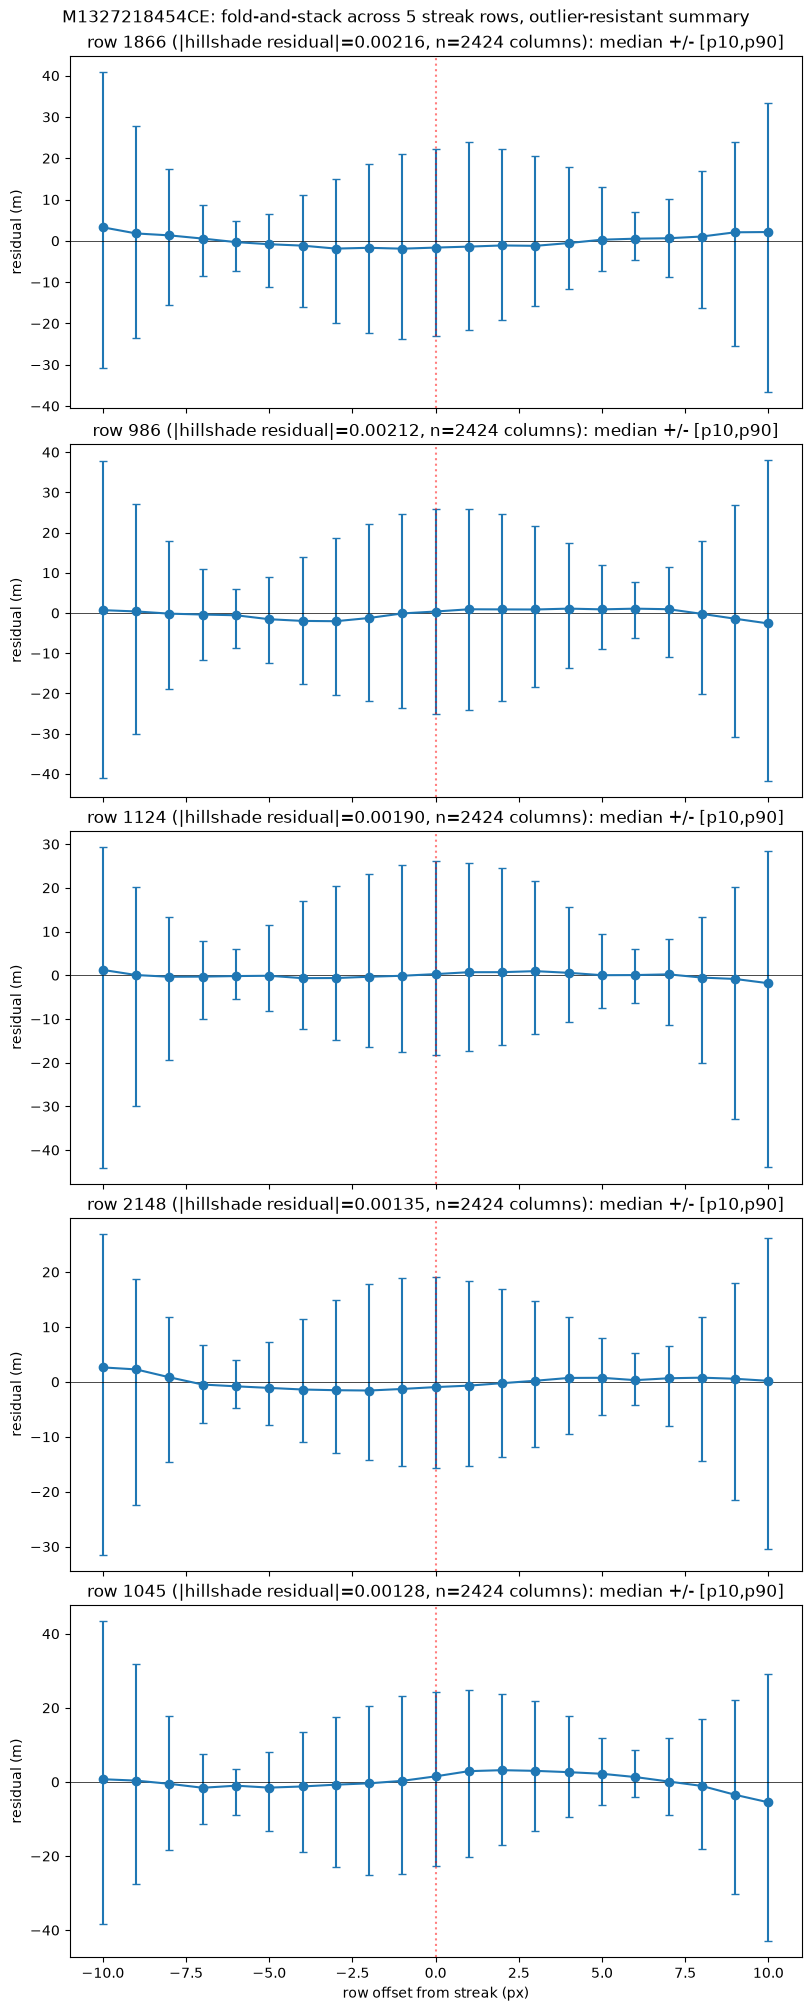

In [8]:
def fold_and_stack(elev, r0, half=10):
    lo, hi = r0 - half, r0 + half + 1
    x = np.arange(-half, half + 1)
    window_elev = elev[lo:hi, :]
    valid_cols = ~np.isnan(window_elev).any(axis=0)
    we = window_elev[:, valid_cols]

    xm = x.mean()
    dx = x - xm
    denom = np.sum(dx**2)
    col_mean = we.mean(axis=0)
    b = (dx[:, None] * (we - col_mean[None, :])).sum(axis=0) / denom
    a = col_mean - b * xm
    baseline = a[None, :] + np.outer(x, b)
    residual = we - baseline  # (21, n_valid_cols)

    p10, p50, p90 = np.percentile(residual, [10, 50, 90], axis=1)
    return x, p10, p50, p90, residual.shape[1]


in_bounds = [r for r in hs_peaks if r - 10 >= 0 and r + 10 < height]
top5_rows = sorted(in_bounds, key=lambda r: abs(hs_residual[r]), reverse=True)[:5]
print(f"selected rows (5 strongest hillshade-flagged peaks): {top5_rows}")

fig, axes = plt.subplots(5, 1, figsize=(8, 20), constrained_layout=True, sharex=True)
for ax, r0 in zip(axes, top5_rows, strict=True):
    x, p10, p50, p90, n_cols = fold_and_stack(elev, r0)
    yerr = np.vstack([p50 - p10, p90 - p50])
    ax.errorbar(x, p50, yerr=yerr, fmt="o-", capsize=3, color="tab:blue")
    ax.axvline(0, color="red", linestyle=":", alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("residual (m)")
    ax.set_title(
        f"row {r0} (|hillshade residual|={abs(hs_residual[r0]):.5f}, n={n_cols} columns): median +/- [p10,p90]"
    )
axes[-1].set_xlabel("row offset from streak (px)")
fig.suptitle(f"{entry.edr_product}: fold-and-stack across 5 streak rows, outlier-resistant summary")
fig.savefig(config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_streak_fold_5rows.png", dpi=150)
plt.show()

The median stays near zero throughout (no coherent directional shift -- argues against a simple
biased-step model). But the p10-p90 *spread* visibly widens right at x=0 in every panel above.
Quantified below: is that widening at the streak real, or just eyeballing noise?

In [9]:
print(f"{'row':>6}  {'spread@-1':>10}  {'spread@0':>10}  {'spread@+1':>10}  {'ratio (0 / avg(-1,+1))':>22}")
for r0 in top5_rows:
    x, p10, p50, p90, n_cols = fold_and_stack(elev, r0)
    spread = p90 - p10
    i_m1, i_0, i_p1 = np.where(x == -1)[0][0], np.where(x == 0)[0][0], np.where(x == 1)[0][0]
    neighbor_avg = (spread[i_m1] + spread[i_p1]) / 2
    print(
        f"{r0:>6}  {spread[i_m1]:>10.3f}  {spread[i_0]:>10.3f}  {spread[i_p1]:>10.3f}  "
        f"{spread[i_0] / neighbor_avg:>22.2f}"
    )
print(
    "-> essentially flat (ratio ~1.0-1.04): no real localized-variance spike at the streak "
    "row -- the apparent widening in the plots above was a visual illusion, not a real effect."
)

   row   spread@-1    spread@0   spread@+1  ratio (0 / avg(-1,+1))
  1866      44.825      45.367      45.732                    1.00
   986      48.334      50.971      49.972                    1.04
  1124      42.705      44.283      43.155                    1.03
  2148      34.344      34.816      33.578                    1.03
  1045      48.133      46.933      44.899                    1.01
-> essentially flat (ratio ~1.0-1.04): no real localized-variance spike at the streak row -- the apparent widening in the plots above was a visual illusion, not a real effect.


The median itself, then -- is there a real, localized deviation at x=0 distinguishable from its
immediate neighborhood, even if small?

In [10]:
for r0 in top5_rows:
    x, p10, p50, p90, n_cols = fold_and_stack(elev, r0)
    print(f"\nrow {r0} median residual (m) by row offset:")
    print("  " + "  ".join(f"{xi:+d}:{p:+.2f}" for xi, p in zip(x, p50, strict=True)))


row 1866 median residual (m) by row offset:
  -10:+3.27  -9:+1.79  -8:+1.32  -7:+0.54  -6:-0.31  -5:-0.82  -4:-1.16  -3:-1.88  -2:-1.69  -1:-1.90  +0:-1.64  +1:-1.40  +2:-1.12  +3:-1.22  +4:-0.54  +5:+0.27  +6:+0.52  +7:+0.62  +8:+1.04  +9:+2.06  +10:+2.13

row 986 median residual (m) by row offset:
  -10:+0.70  -9:+0.38  -8:-0.17  -7:-0.39  -6:-0.57  -5:-1.55  -4:-1.97  -3:-2.05  -2:-1.25  -1:-0.11  +0:+0.36  +1:+0.92  +2:+0.89  +3:+0.87  +4:+1.08  +5:+0.90  +6:+1.08  +7:+0.94  +8:-0.22  +9:-1.43  +10:-2.61

row 1124 median residual (m) by row offset:
  -10:+1.22  -9:+0.04  -8:-0.35  -7:-0.32  -6:-0.19  -5:-0.12  -4:-0.67  -3:-0.64  -2:-0.35  -1:-0.12  +0:+0.26  +1:+0.69  +2:+0.70  +3:+0.94  +4:+0.55  +5:+0.01  +6:+0.04  +7:+0.20  +8:-0.54  +9:-0.85  +10:-1.83

row 2148 median residual (m) by row offset:
  -10:+2.63  -9:+2.27  -8:+0.83  -7:-0.49  -6:-0.81  -5:-1.10  -4:-1.39  -3:-1.52  -2:-1.58  -1:-1.29  +0:-0.95  +1:-0.68  +2:-0.24  +3:+0.20  +4:+0.71  +5:+0.74  +6:+0.31  +7:+0.65 

## Control: does a non-flagged row show the same shape?

All five medians above dip negative on the left half of the window and rise positive on the
right, with *the same sign* every time. That consistency could mean something real about the
streaks -- or it could just mean a linear fit over any +/-10 px window in genuinely concave-up
terrain produces exactly this "dip then rise" shape, streak or not, in which case the pattern
above has nothing to do with the artifact. Rerun the identical diagnostic on rows *not* flagged
by the hillshade detector to check.

control rows (not near any hillshade-flagged streak): [751, 819, 1392, 1600, 2226]

control row 751 median residual (m) by row offset:
  -10:-1.81  -9:-1.13  -8:-0.45  -7:+0.05  -6:+0.47  -5:+0.55  -4:+0.52  -3:+0.53  -2:+0.65  -1:+0.67  +0:+0.78  +1:+0.52  +2:+0.11  +3:-0.10  +4:-0.01  +5:+0.02  +6:-0.10  +7:-0.19  +8:-0.62  +9:-0.42  +10:-0.11

control row 819 median residual (m) by row offset:
  -10:-0.31  -9:-0.30  -8:-0.02  -7:-0.00  -6:-0.05  -5:+0.24  -4:+0.15  -3:+0.31  -2:+0.32  -1:+0.03  +0:+0.01  +1:-0.10  +2:-0.20  +3:-0.10  +4:+0.21  +5:+0.23  +6:+0.14  +7:-0.06  +8:+0.09  +9:+0.32  +10:+0.83

control row 1392 median residual (m) by row offset:
  -10:+4.24  -9:+3.21  -8:+2.06  -7:+1.06  -6:+0.13  -5:-0.61  -4:-1.03  -3:-1.59  -2:-2.11  -1:-2.40  +0:-2.85  +1:-2.83  +2:-2.63  +3:-2.25  +4:-1.72  +5:-0.89  +6:+0.06  +7:+0.75  +8:+2.26  +9:+3.49  +10:+4.77

control row 1600 median residual (m) by row offset:
  -10:+3.02  -9:+2.44  -8:+2.29  -7:+1.33  -6:+0.48  -5:-0.12  -4:-0

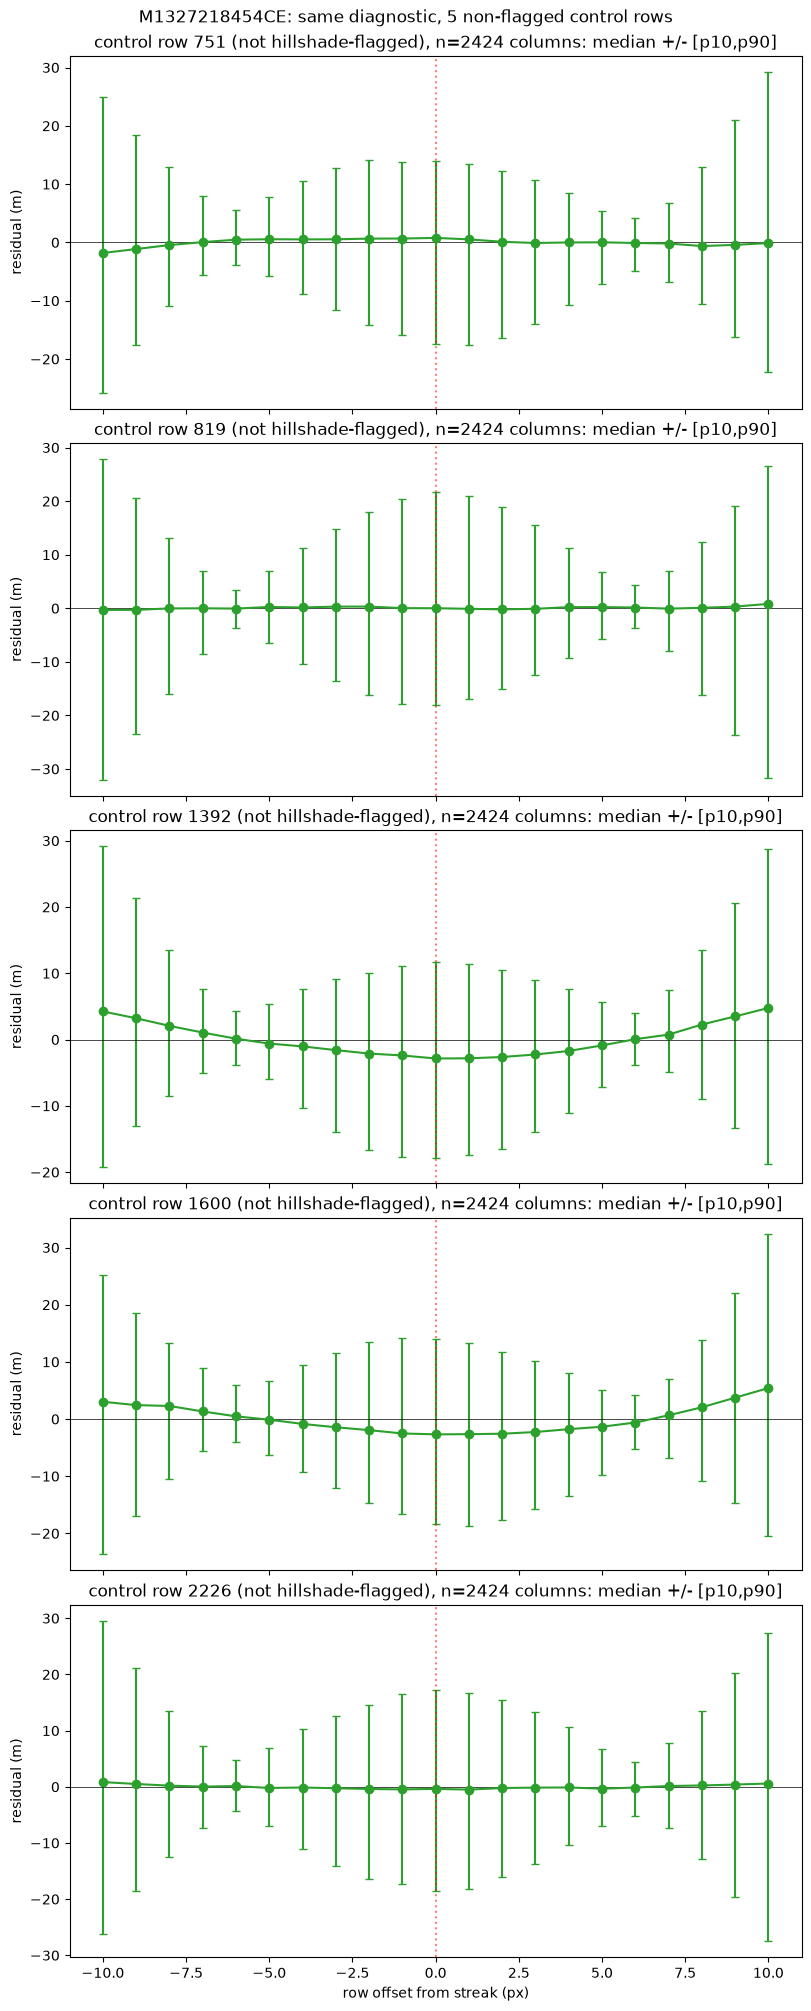

In [11]:
rng = np.random.default_rng(0)
flagged_nearby = set()
for r in hs_peaks:
    flagged_nearby.update(range(r - 15, r + 16))  # exclude anything within 15 rows of a real flag
candidate_controls = [r for r in range(15, height - 15) if r not in flagged_nearby]
control_rows = rng.choice(candidate_controls, size=5, replace=False)
control_rows.sort()
print(f"control rows (not near any hillshade-flagged streak): {control_rows.tolist()}")

fig, axes = plt.subplots(5, 1, figsize=(8, 20), constrained_layout=True, sharex=True)
for ax, r0 in zip(axes, control_rows, strict=True):
    x, p10, p50, p90, n_cols = fold_and_stack(elev, r0)
    yerr = np.vstack([p50 - p10, p90 - p50])
    ax.errorbar(x, p50, yerr=yerr, fmt="o-", capsize=3, color="tab:green")
    ax.axvline(0, color="red", linestyle=":", alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("residual (m)")
    ax.set_title(f"control row {r0} (not hillshade-flagged), n={n_cols} columns: median +/- [p10,p90]")
    print(f"\ncontrol row {r0} median residual (m) by row offset:")
    print("  " + "  ".join(f"{xi:+d}:{p:+.2f}" for xi, p in zip(x, p50, strict=True)))
axes[-1].set_xlabel("row offset from streak (px)")
fig.suptitle(f"{entry.edr_product}: same diagnostic, 5 non-flagged control rows")
fig.savefig(config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_streak_fold_5controls.png", dpi=150)
plt.show()

## Raw column data: a 10x10 grid instead of an aggregate

Every check so far has aggregated across ~2400 columns first -- mean, median, spread -- and every
one of those aggregates turned out to be misleading in some way (outlier columns skewing the mean;
a "widening" that wasn't real; a shape indistinguishable from ordinary terrain curvature). Skip
aggregation entirely: plot 100 individual columns' own raw elevation profiles (no detrending, no
stacking), narrowed to x = -5..+5, so the actual per-column shape is visible directly. Done for
the clearest flagged row (1045) and, for direct comparison, the strongest control row (1392) --
same construction, same column sampling, side by side.

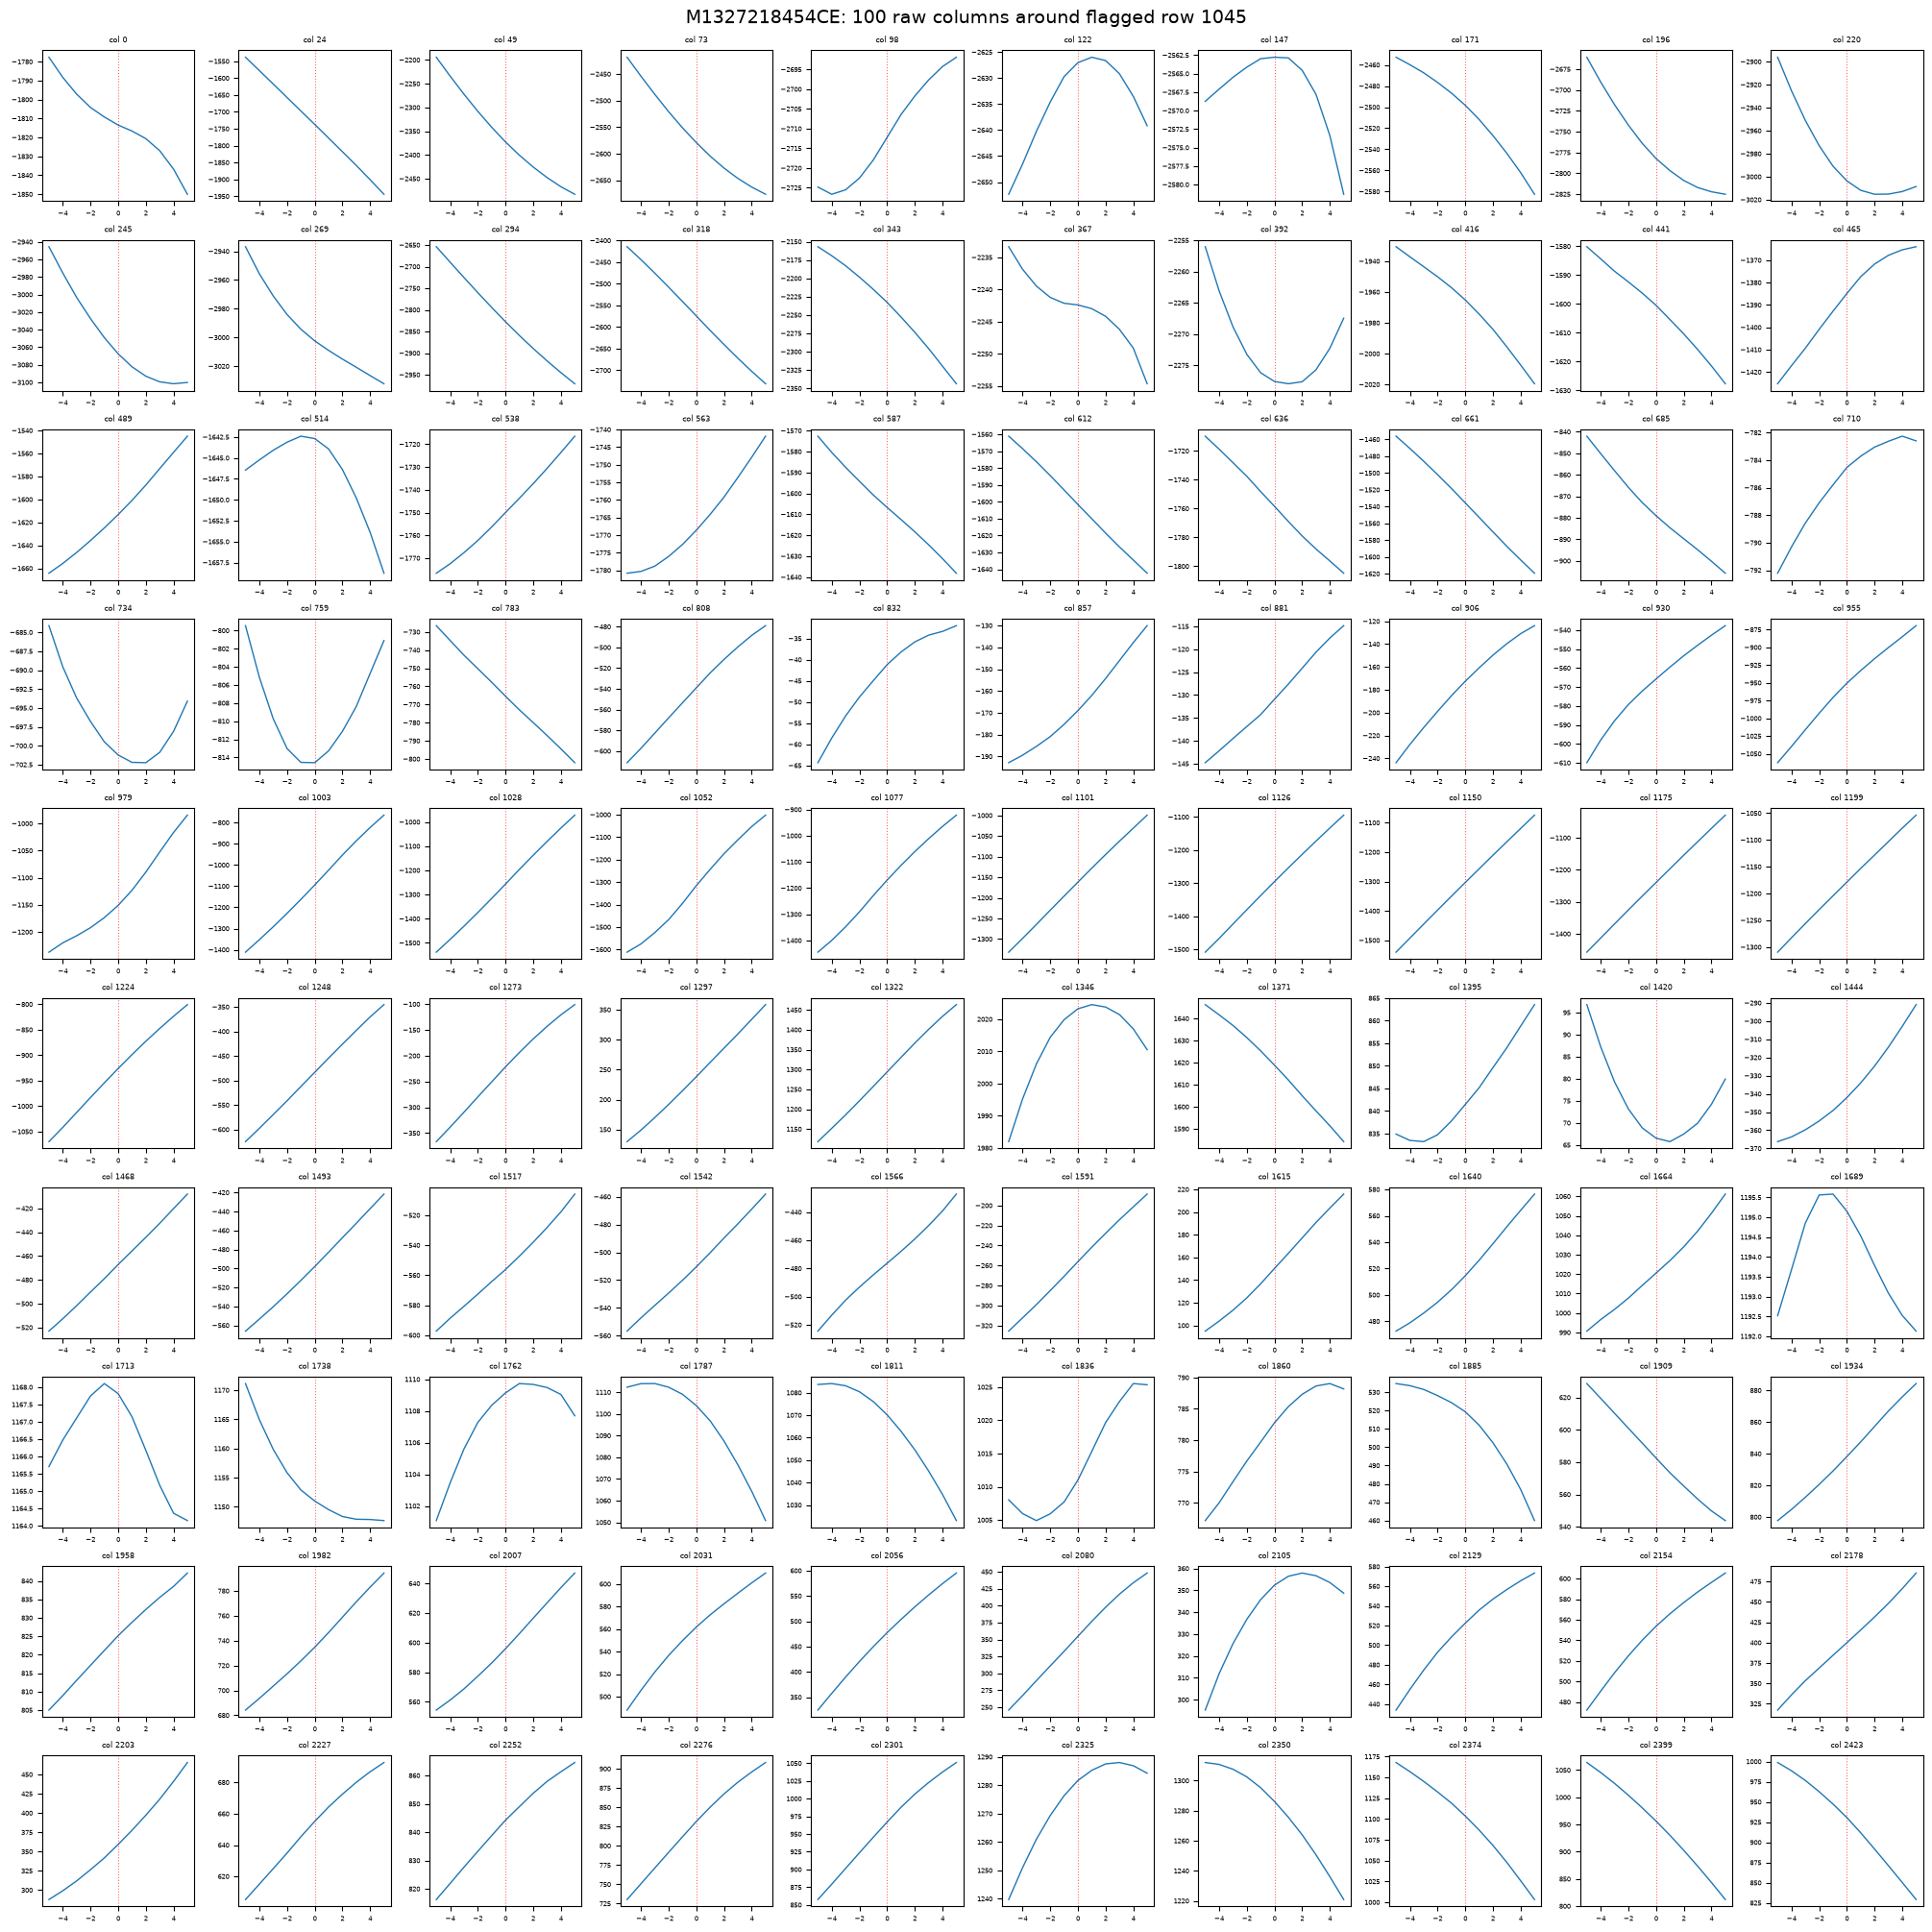

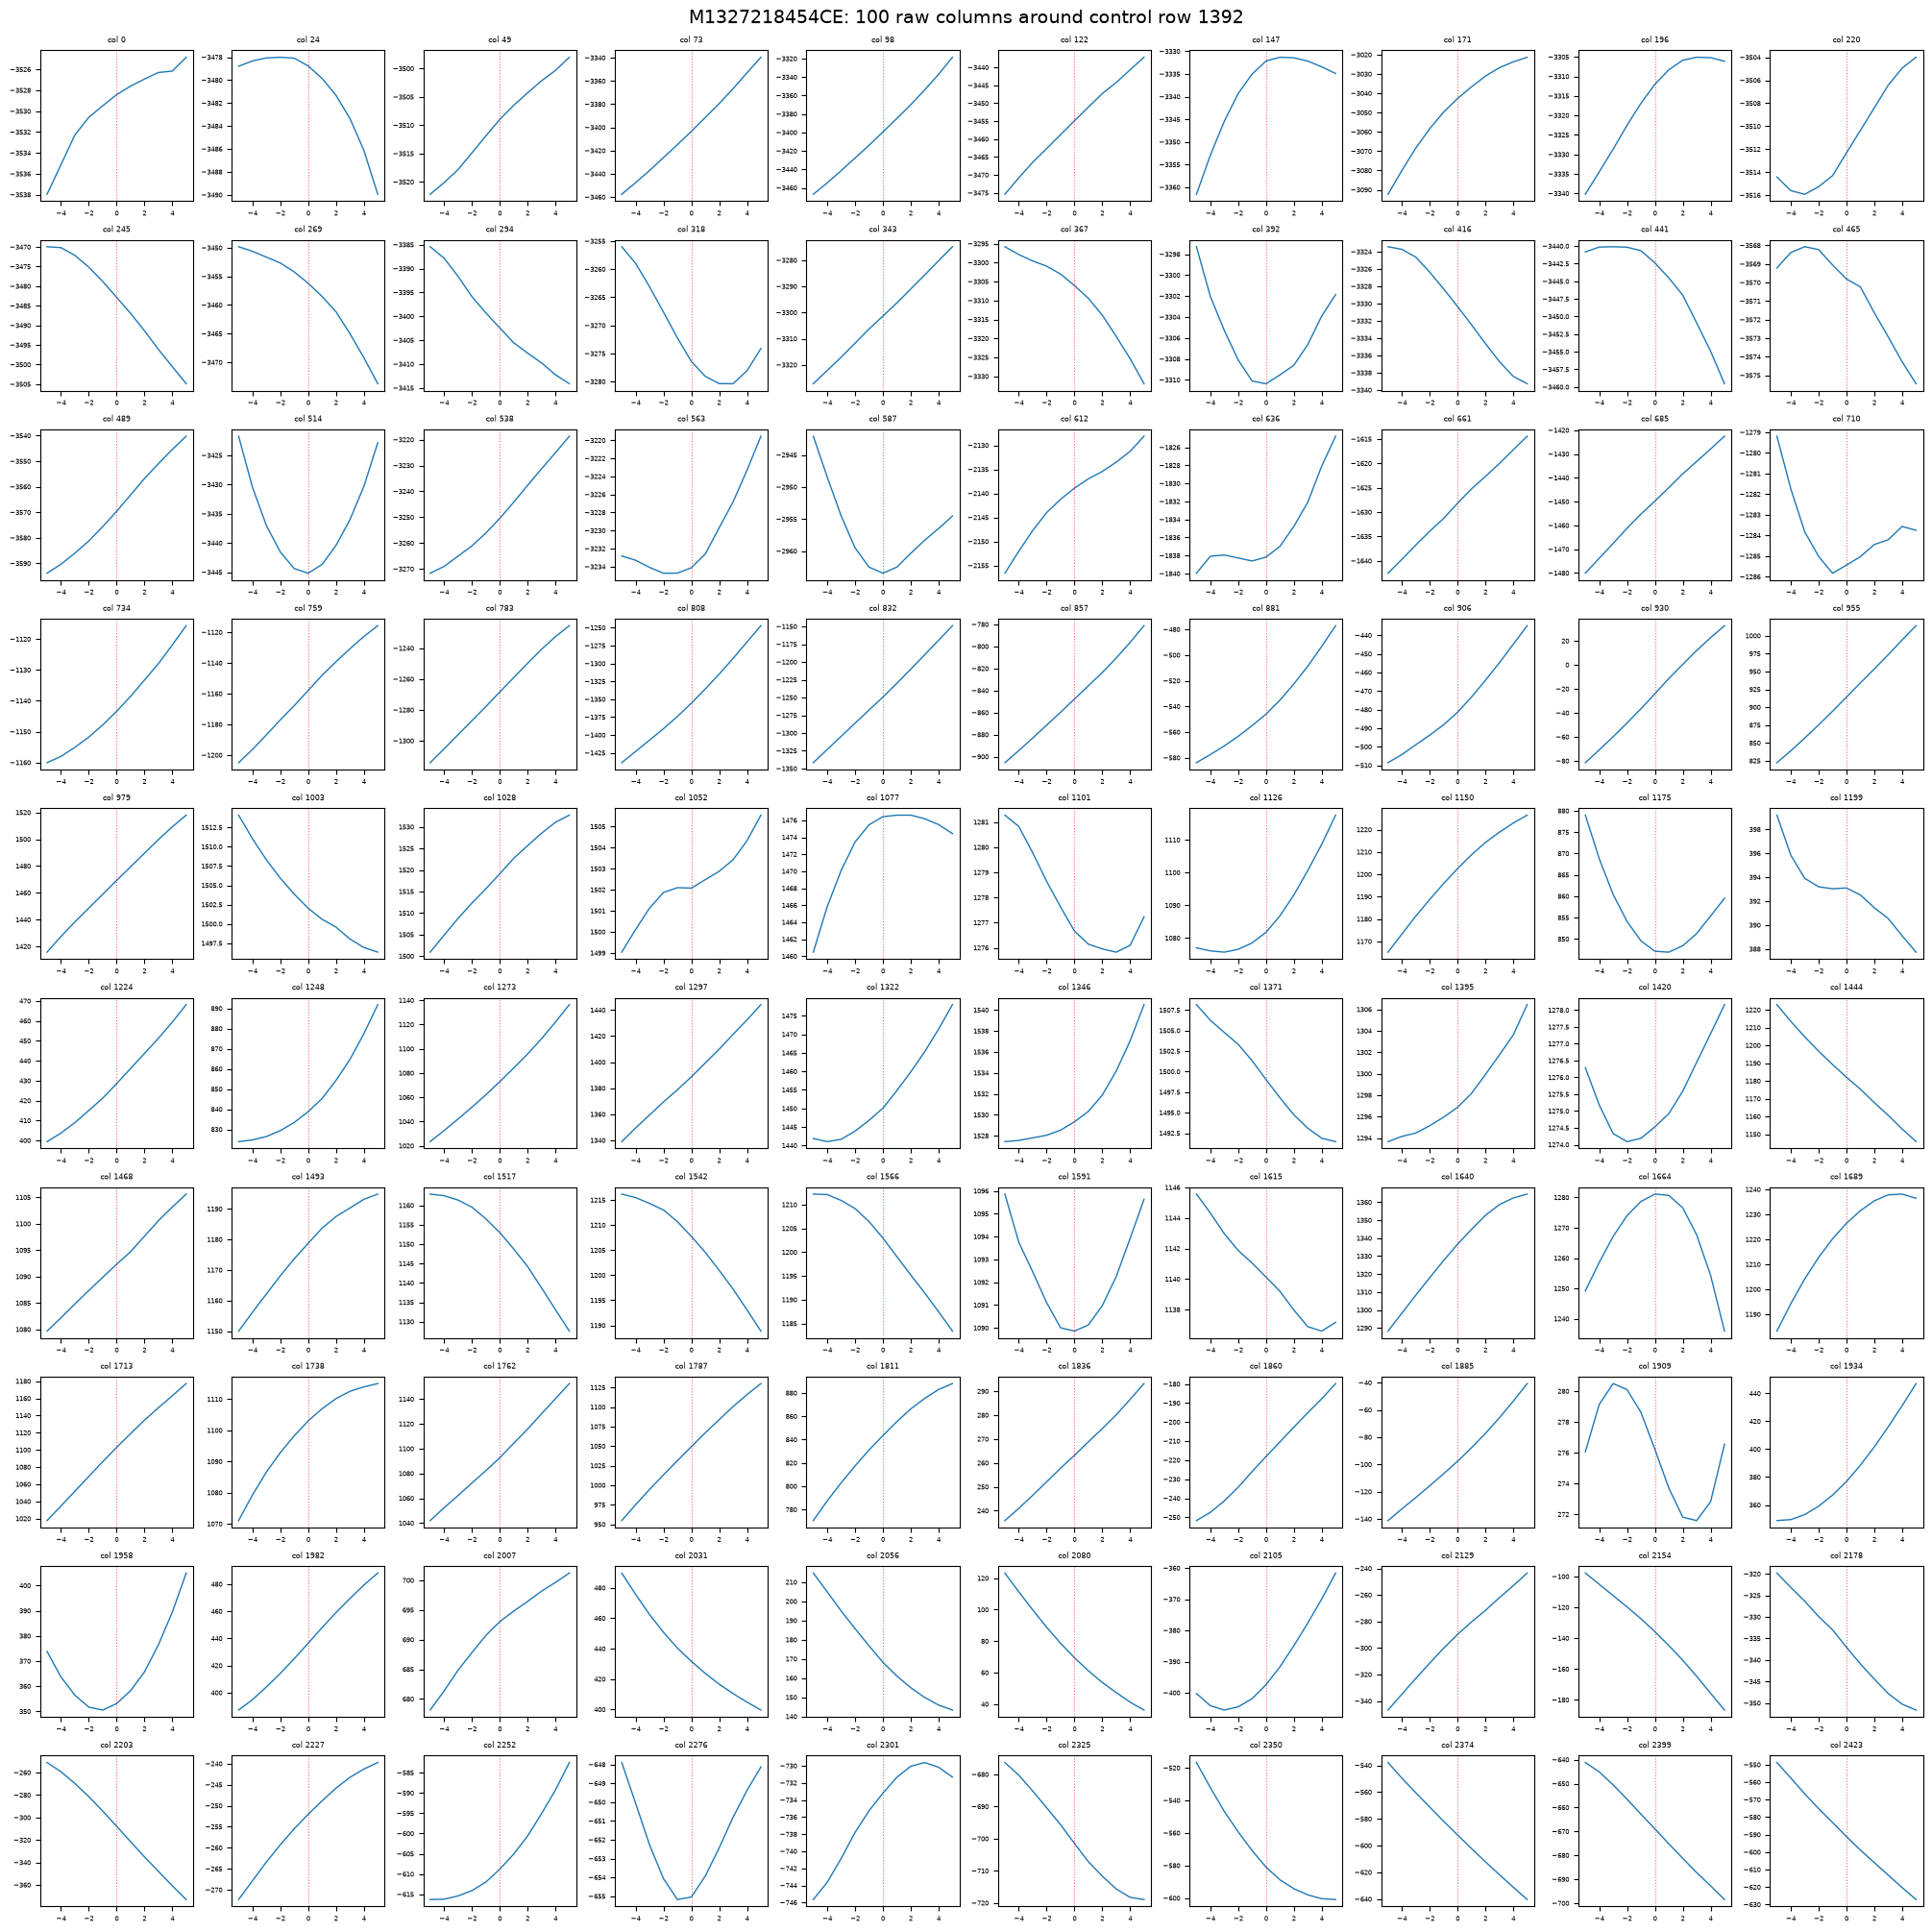

In [12]:
def plot_raw_column_grid(elev, r0, title, half=5, n_cols=100):
    lo, hi = r0 - half, r0 + half + 1
    x = np.arange(-half, half + 1)
    col_idx = np.linspace(0, elev.shape[1] - 1, n_cols).round().astype(int)
    window_elev = elev[lo:hi, :][:, col_idx]  # (2*half+1, n_cols)

    grid = int(np.sqrt(n_cols))
    fig, axes = plt.subplots(grid, grid, figsize=(20, 20), constrained_layout=True)
    for ax, c, ci in zip(axes.flat, col_idx, range(n_cols), strict=True):
        profile = window_elev[:, ci]
        ax.plot(x, profile, "-", color="tab:blue", linewidth=1)
        ax.axvline(0, color="red", linestyle=":", alpha=0.6, linewidth=0.8)
        ax.set_title(f"col {c}", fontsize=6)
        ax.tick_params(labelsize=5)
    fig.suptitle(title, fontsize=14)
    return fig


fig1 = plot_raw_column_grid(elev, 1045, f"{entry.edr_product}: 100 raw columns around flagged row 1045")
fig1.savefig(config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_raw_columns_row1045.png", dpi=120)
plt.show()

fig2 = plot_raw_column_grid(elev, 1392, f"{entry.edr_product}: 100 raw columns around control row 1392")
fig2.savefig(config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_raw_columns_row1392.png", dpi=120)
plt.show()